In [ ]:
!pip install -q wandb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/bitirme_modeller/matchmaker_newversion_arda
!ls
!ls data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/bitirme_modeller/matchmaker_newversion_arda
 architecture.txt
 cell_line_order.txt
 data
 drugChemFeatParser.py
 drug_chem_rdkit.csv
 drug_chem_rdkit_descriptors_clean.csv
 gex_gene_order.txt
 helper_funcs.py
 main.py
 MatchMaker.py
'meeting4 (1).ipynb'
 meeting4.ipynb
 performance_metrics.py
 __pycache__
 results_602020_seed42
 results_801010_seed42
 results_phase1
 results_seed43
 results_seed44
 triplet_stats_quartiles_filtered_iqr.csv
 wandb
cell_line_gex.csv	  drug1_chem.csv  DrugCombinationData.tsv
cell_line_gex_tmpfix.csv  drug2_chem.csv


In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ardathewonderful (ardathewonderful-sa) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import pandas as pd

combo = pd.read_csv("data/DrugCombinationData.tsv", sep="\t")
drug1 = pd.read_csv("data/drug1_chem.csv", header=None)
drug2 = pd.read_csv("data/drug2_chem.csv", header=None)
cell  = pd.read_csv("data/cell_line_gex.csv", header=None)

print("Combo:", combo.shape)
print("Drug1:", drug1.shape)
print("Drug2:", drug2.shape)
print("Cell :", cell.shape)

assert len(combo) == len(drug1) == len(drug2) == len(cell), "Row mismatch!"
print("All files aligned.")

Combo: (8702, 4)
Drug1: (8702, 217)
Drug2: (8702, 217)
Cell : (8702, 972)
All files aligned.


In [ ]:
with open("architecture.txt", "w") as f:
    f.write("DSN_1,DSN_2,SPN\n")
    f.write("2048-4096-2048,2048-4096-2048,2048-1024\n")

!cat architecture.txt

DSN_1,DSN_2,SPN
2048-4096-2048,2048-4096-2048,2048-1024


In [ ]:
import pandas as pd
import numpy as np

combo = pd.read_csv("data/DrugCombinationData.tsv", sep="\t")
drug1 = pd.read_csv("data/drug1_chem.csv", header=None)
drug2 = pd.read_csv("data/drug2_chem.csv", header=None)
cell  = pd.read_csv("data/cell_line_gex.csv", header=None)

print("combo NaN in target:", combo["synergy_loewe"].isna().sum())
print("combo inf in target:", np.isinf(combo["synergy_loewe"]).sum())

print("drug1 NaN:", drug1.isna().sum().sum())
print("drug2 NaN:", drug2.isna().sum().sum())
print("cell  NaN:", cell.isna().sum().sum())

print("drug1 inf:", np.isinf(drug1.values).sum())
print("drug2 inf:", np.isinf(drug2.values).sum())
print("cell  inf:", np.isinf(cell.values).sum())

print("drug1 min/max:", np.nanmin(drug1.values), np.nanmax(drug1.values))
print("drug2 min/max:", np.nanmin(drug2.values), np.nanmax(drug2.values))
print("cell  min/max:", np.nanmin(cell.values), np.nanmax(cell.values))
print("target min/max:", combo["synergy_loewe"].min(), combo["synergy_loewe"].max())

combo NaN in target: 0
combo inf in target: 0
drug1 NaN: 0
drug2 NaN: 0
cell  NaN: 374186
drug1 inf: 0
drug2 inf: 0
cell  inf: 0
drug1 min/max: -10.892473742657696 1000000.0
drug2 min/max: -10.892473742657696 1000000.0
cell  min/max: 0.0 13.401
target min/max: -6.593920925 6.9768413875


In [ ]:
import pandas as pd
import numpy as np

cell = pd.read_csv("data/cell_line_gex.csv", header=None)

# rows that are entirely NaN
all_nan_rows = cell.isna().all(axis=1)

print("Number of fully-NaN rows:", all_nan_rows.sum())
print("Indices of fully-NaN rows:", list(cell.index[all_nan_rows])[:20])

# rows with any NaN
any_nan_rows = cell.isna().any(axis=1)
print("Rows with any NaN:", any_nan_rows.sum())

Number of fully-NaN rows: 0
Indices of fully-NaN rows: []
Rows with any NaN: 8702


In [ ]:
combo = pd.read_csv("data/DrugCombinationData.tsv", sep="\t")

bad_idx = cell.index[cell.isna().all(axis=1)]
print(combo.iloc[bad_idx][["drug1_id", "drug2_id", "cell_line"]].head(20))

Empty DataFrame
Columns: [drug1_id, drug2_id, cell_line]
Index: []


In [ ]:
cell = pd.read_csv("data/cell_line_gex.csv", header=None)
cell = cell.fillna(0.0)
cell.to_csv("data/cell_line_gex_tmpfix.csv", header=False, index=False)
print("Temporary fixed file saved.")

Temporary fixed file saved.


In [ ]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name sanity_matchmaker.h5 \
  --outdir results_phase1 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name phase1_sanity_seed42

2026-04-09 19:33:15.747715: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 19:33:15.760080: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 19:33:15.787029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775763195.828345   21819 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775763195.840207   21819 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775763195.893100   21819 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [ ]:
import pandas as pd
pd.read_csv("results_phase1/results.csv")

,tag,mse,spearman,pearson
0,random_seed42,0.617748,0.817946,0.852497


In [ ]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 43 \
  --arch architecture.txt \
  --saved-model-name sanity_matchmaker.h5 \
  --outdir results_seed43 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name phase2_seed43

2026-04-09 20:35:55.970895: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 20:35:55.990539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775766956.012232   20160 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775766956.019327   20160 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775766956.036346   20160 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 44 \
  --arch architecture.txt \
  --saved-model-name sanity_matchmaker.h5 \
  --outdir results_seed44 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name phase2_seed44

2026-04-09 20:39:26.333297: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 20:39:26.353357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775767166.375921   31226 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775767166.383288   31226 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775767166.400822   31226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
import pandas as pd

r42 = pd.read_csv("results_phase1/results.csv")
r43 = pd.read_csv("results_seed43/results.csv")
r44 = pd.read_csv("results_seed44/results.csv")

all_res = pd.concat([r42, r43, r44], ignore_index=True)
print(all_res)

print("\nMean metrics:")
print(all_res[["mse", "spearman", "pearson"]].mean())

print("\nStd metrics:")
print(all_res[["mse", "spearman", "pearson"]].std())

             tag       mse  spearman   pearson
0  random_seed42  0.617748  0.817946  0.852497
1  random_seed43  0.845830  0.820552  0.843837
2  random_seed44  0.704239  0.792231  0.811520

Mean metrics:
mse         0.722605
spearman    0.810243
pearson     0.835951
dtype: float64

Std metrics:
mse         0.115145
spearman    0.015653
pearson     0.021596
dtype: float64


In [ ]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name baseline_801010.h5 \
  --outdir results_801010_seed42 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name baseline_801010_seed42

2026-04-09 20:44:46.802193: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 20:44:46.821877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775767486.843816   43321 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775767486.851000   43321 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775767486.867980   43321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.6 0.2 0.2 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name baseline_602020.h5 \
  --outdir results_602020_seed42 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name baseline_602020_seed42

2026-04-10 07:35:25.674807: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 07:35:25.694944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775806525.718167    3137 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775806525.725826    3137 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775806525.743617    3137 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
import numpy as np

def load_inds(path):
    return set(np.loadtxt(path, dtype=int))

train42 = load_inds("results_phase1/train_random_seed42.txt")
train43 = load_inds("results_seed43/train_random_seed43.txt")
train44 = load_inds("results_seed44/train_random_seed44.txt")

print("Train overlap 42 vs 43:", len(train42 & train43))
print("Train overlap 42 vs 44:", len(train42 & train44))
print("Train overlap 43 vs 44:", len(train43 & train44))

Train overlap 42 vs 43: 5580
Train overlap 42 vs 44: 5578
Train overlap 43 vs 44: 5584


In [ ]:
def overlap_ratio(a, b):
    return len(a & b) / len(a)

print("42 vs 43:", overlap_ratio(train42, train43))
print("42 vs 44:", overlap_ratio(train42, train44))
print("43 vs 44:", overlap_ratio(train43, train44))

42 vs 43: 0.8016089642292774
42 vs 44: 0.801321649188335
43 vs 44: 0.8021835943111622


In [ ]:
import numpy as np

def load_inds(path):
    return set(np.loadtxt(path, dtype=int))

train42 = load_inds("results_phase1/val_random_seed42.txt")
train43 = load_inds("results_seed43/val_random_seed43.txt")
train44 = load_inds("results_seed44/val_random_seed44.txt")

print("Val overlap 42 vs 43:", len(train42 & train43))
print("Val overlap 42 vs 44:", len(train42 & train44))
print("Val overlap 43 vs 44:", len(train43 & train44))

Val overlap 42 vs 43: 97
Val overlap 42 vs 44: 87
Val overlap 43 vs 44: 91


In [ ]:
def overlap_ratio(a, b):
    return len(a & b) / len(a)

print("42 vs 43:", overlap_ratio(train42, train43))
print("42 vs 44:", overlap_ratio(train42, train44))
print("43 vs 44:", overlap_ratio(train43, train44))

42 vs 43: 0.11149425287356322
42 vs 44: 0.1
43 vs 44: 0.10459770114942529


In [ ]:
import numpy as np

def load_inds(path):
    return set(np.loadtxt(path, dtype=int))

train42 = load_inds("results_phase1/test_random_seed42.txt")
train43 = load_inds("results_seed43/test_random_seed43.txt")
train44 = load_inds("results_seed44/test_random_seed44.txt")

print("Test overlap 42 vs 43:", len(train42 & train43))
print("Test overlap 42 vs 44:", len(train42 & train44))
print("Test overlap 43 vs 44:", len(train43 & train44))

Test overlap 42 vs 43: 82
Test overlap 42 vs 44: 73
Test overlap 43 vs 44: 88


In [ ]:
def overlap_ratio(a, b):
    return len(a & b) / len(a)

print("42 vs 43:", overlap_ratio(train42, train43))
print("42 vs 44:", overlap_ratio(train42, train44))
print("43 vs 44:", overlap_ratio(train43, train44))

42 vs 43: 0.09414466130884042
42 vs 44: 0.08381171067738231
43 vs 44: 0.1010332950631458


In [ ]:
import pandas as pd

r42 = pd.read_csv("results_801010_seed42/results.csv")
r43 = pd.read_csv("results_602020_seed42/results.csv")

all_res = pd.concat([r42, r43], ignore_index=True)
print(all_res)

print("\nMean metrics:")
print(all_res[["mse", "spearman", "pearson"]].mean())

print("\nStd metrics:")
print(all_res[["mse", "spearman", "pearson"]].std())

             tag       mse  spearman   pearson
0  random_seed42  0.622795  0.803779  0.839717
1  random_seed42  0.714559  0.785001  0.809673

Mean metrics:
mse         0.668677
spearman    0.794390
pearson     0.824695
dtype: float64

Std metrics:
mse         0.064887
spearman    0.013278
pearson     0.021244
dtype: float64


In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf

import MatchMaker as MM
import performance_metrics as pm

# =========================
# CONFIG
# =========================
COMBO_PATH = "data/DrugCombinationData.tsv"
DRUG1_PATH = "data/drug1_chem.csv"
DRUG2_PATH = "data/drug2_chem.csv"
CELL_PATH  = "data/cell_line_gex.csv"
ARCH_PATH  = "architecture.txt"

# Use the same split settings as the run you want to evaluate
SEED = 42
SPLIT = (0.8, 0.1, 0.1)

# model path from your completed run
MODEL_PATH = "results_phase1/random_seed42_sanity_matchmaker.h5"

# quartiles from your earlier analysis
Q1 = -0.8386991786153846
Q3 = 0.844086120625

NORM = "tanh_norm"
INPUT_DROPOUT = 0.2
DROPOUT = 0.5

# =========================
# LOAD DATA
# =========================
chem1, chem2, cell_line, synergies = MM.data_loader(
    DRUG1_PATH, DRUG2_PATH, CELL_PATH, COMBO_PATH
)

N = len(synergies)
idx = np.arange(N)

# recreate the same random split
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

n_tr = int(SPLIT[0] * N)
n_va = int(SPLIT[1] * N)

train_idx = idx[:n_tr]
val_idx   = idx[n_tr:n_tr+n_va]
test_idx  = idx[n_tr+n_va:]

np.savetxt("tmp_train_eval.txt", train_idx, fmt="%d")
np.savetxt("tmp_val_eval.txt", val_idx, fmt="%d")
np.savetxt("tmp_test_eval.txt", test_idx, fmt="%d")

train_data, val_data, test_data = MM.prepare_data(
    chem1, chem2, cell_line, synergies,
    NORM,
    "tmp_train_eval.txt",
    "tmp_val_eval.txt",
    "tmp_test_eval.txt"
)

# =========================
# LOAD ARCHITECTURE
# =========================
architecture = pd.read_csv(ARCH_PATH)
layers = {
    "DSN_1": architecture["DSN_1"][0],
    "DSN_2": architecture["DSN_2"][0],
    "SPN": architecture["SPN"][0],
}

# build same model and load weights
model = MM.generate_network(train_data, layers, INPUT_DROPOUT, DROPOUT)
model.load_weights(MODEL_PATH)

# =========================
# PREDICT
# =========================
pred1 = MM.predict(model, [test_data["drug1"], test_data["drug2"]])
pred2 = MM.predict(model, [test_data["drug2"], test_data["drug1"]])
y_pred = (pred1 + pred2) / 2
y_true = test_data["y"]

print("Test set size:", len(y_true))

# =========================
# REGRESSION METRICS
# =========================
print("\n===== REGRESSION METRICS =====")
mse_val = pm.mse(y_true, y_pred)
spearman_val = pm.spearman(y_true, y_pred)
pearson_val = pm.pearson(y_true, y_pred)

# =========================
# CLASSIFICATION: THRESHOLD 0
# =========================
print("\n===== CLASSIFICATION @ THRESHOLD 0 =====")
res_zero = pm.classification_metrics(y_true, y_pred, threshold=0.0)

# =========================
# CLASSIFICATION: QUARTILE FILTERED
# =========================
print("\n===== CLASSIFICATION @ QUARTILE THRESHOLDS =====")
res_quart = pm.classification_metrics_filtered(y_true, y_pred, low_thr=Q1, high_thr=Q3)

# =========================
# OPTIONAL: STORE PREDICTIONS
# =========================
pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred
})

pred_df.to_csv("test_predictions_seed42.csv", index=False)
print("\nSaved predictions to test_predictions_seed42.csv")

File reading ...
Data normalization and preparation of train/validation/test data
(871, 1103)
(871, 1103)
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 181ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Test set size: 871

===== REGRESSION METRICS =====
Mean squared error is 0.6463835707884603
Spearman correlation is 0.7851743097473477 and related p_value is 4.827511796059241e-183
Pearson correlation is 0.8234729877731674 and related p_value is 4.136508297736561e-216

===== CLASSIFICATION @ THRESHOLD 0 =====
Threshold = 0.0
Accuracy = 0.7876004592422503
F1 = 0.783625730994152
Precision = 0.8014354066985646
Recall = 0.7665903890160183
AUC = 0.873614611563973
Confusion matrix:
[[351  83]
 [102 335]]

===== CLASSIFICATION @ QUARTILE THRESHOLDS =====
Filtered thresholds: low=-0.8386991786153846, high=0.844086120625
N kept = 414
Accuracy = 0.7632850241545893
F1 = 0.6956521739130435
Precision = 1.0
Recall = 0.5333333333333333
AUC = 0.9834500466853408
Confusion matrix:
[[204   0]
 [ 98 112]]

Saved predicti

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# =========================
# THRESHOLD SWEEP
# =========================

thresholds = np.linspace(-1.5, 1.5, 50)

results = []

for t in thresholds:
    y_true_bin = (y_true > t).astype(int)
    y_pred_bin = (y_pred > t).astype(int)

    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    })

df_thresh = pd.DataFrame(results)

print(df_thresh.head())

   threshold  accuracy        f1  precision    recall
0  -1.500000  0.912744  0.953144   0.914793  0.994852
1  -1.438776  0.912744  0.952970   0.914489  0.994832
2  -1.377551  0.902411  0.947040   0.903686  0.994764
3  -1.316327  0.890930  0.940063   0.895433  0.989376
4  -1.255102  0.882893  0.935032   0.886473  0.989218


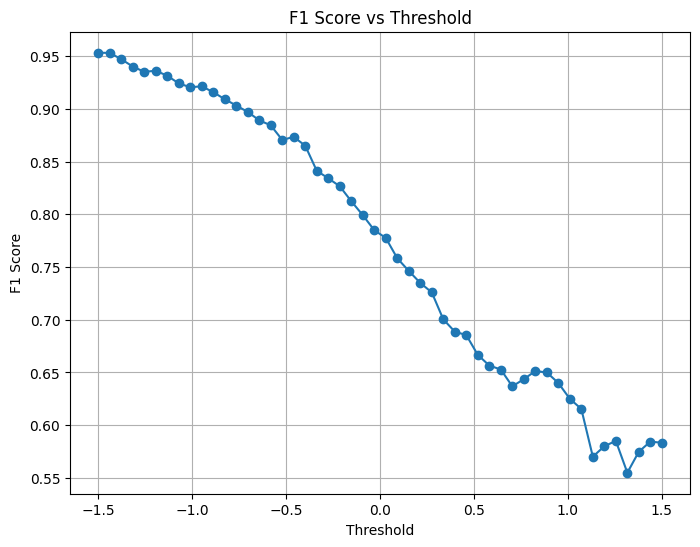

In [6]:
plt.figure(figsize=(8,6))
plt.plot(df_thresh["threshold"], df_thresh["f1"], marker='o')

plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.grid(True)
plt.show()

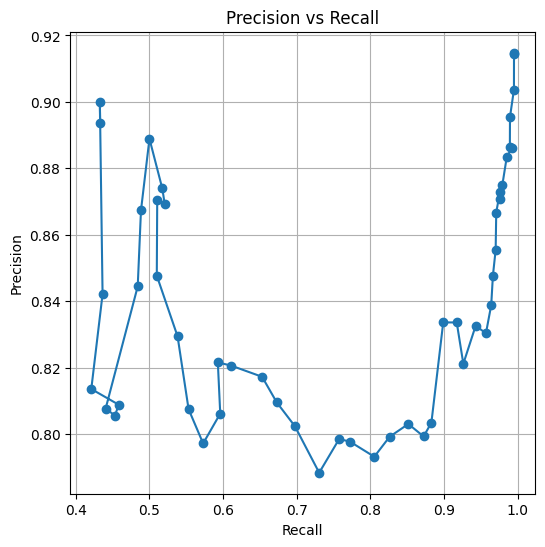

In [7]:
plt.figure(figsize=(6,6))
plt.plot(df_thresh["recall"], df_thresh["precision"], marker='o')

plt.title("Precision vs Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)
plt.show()

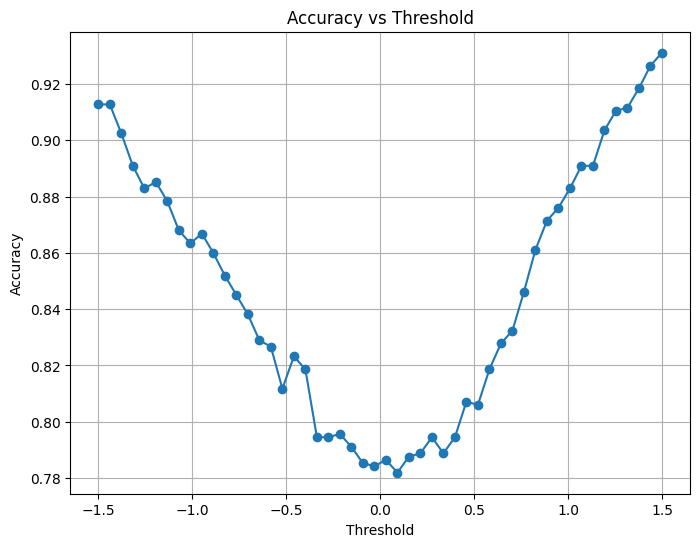

In [8]:
plt.figure(figsize=(8,6))
plt.plot(df_thresh["threshold"], df_thresh["accuracy"], marker='o')

plt.title("Accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

In [9]:
best_row = df_thresh.loc[df_thresh["f1"].idxmax()]

print("\nBest threshold based on F1:")
print(best_row)


Best threshold based on F1:
threshold   -1.500000
accuracy     0.912744
f1           0.953144
precision    0.914793
recall       0.994852
Name: 0, dtype: float64


In [11]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name baseline_uniform.h5 \
  --outdir results_uniform_seed42 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --weight-mode uniform \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name uniform_seed42

2026-04-23 18:44:52.221787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776969892.244271    8322 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776969892.251461    8322 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776969892.268514    8322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776969892.268550    8322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776969892.268553    8322 computation_placer.cc:177] computation placer alr

In [12]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name q3_weighted.h5 \
  --outdir results_q3weighted_seed42 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --weight-mode q3_upweight \
  --weight-alpha 3.0 \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name q3_weighted_seed42

2026-04-23 18:48:31.911146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776970111.933204   18980 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776970111.940394   18980 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776970111.957486   18980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776970111.957522   18980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776970111.957525   18980 computation_placer.cc:177] computation placer alr

In [14]:
import numpy as np
import pandas as pd
import MatchMaker as MM
import performance_metrics as pm

# =========================
# CONFIG
# =========================
COMBO_PATH = "data/DrugCombinationData.tsv"
DRUG1_PATH = "data/drug1_chem.csv"
DRUG2_PATH = "data/drug2_chem.csv"
CELL_PATH  = "data/cell_line_gex.csv"
ARCH_PATH  = "architecture.txt"

# same split settings used during training
SEED = 42
SPLIT = (0.8, 0.1, 0.1)

# model files to compare
MODEL_UNIFORM = "results_uniform_seed42/random_seed42_baseline_uniform.h5"
MODEL_Q3      = "results_q3weighted_seed42/random_seed42_q3_weighted.h5"

# quartiles from your earlier analysis
Q1 = -0.8386991786153846
Q3 = 0.844086120625

# architecture / preprocessing settings
NORM = "tanh_norm"
INPUT_DROPOUT = 0.2
DROPOUT = 0.5

# =========================
# LOAD DATA
# =========================
chem1, chem2, cell_line, synergies = MM.data_loader(
    DRUG1_PATH, DRUG2_PATH, CELL_PATH, COMBO_PATH
)

N = len(synergies)
idx = np.arange(N)

rng = np.random.default_rng(SEED)
rng.shuffle(idx)

n_tr = int(SPLIT[0] * N)
n_va = int(SPLIT[1] * N)

train_idx = idx[:n_tr]
val_idx   = idx[n_tr:n_tr+n_va]
test_idx  = idx[n_tr+n_va:]

np.savetxt("tmp_train_compare.txt", train_idx, fmt="%d")
np.savetxt("tmp_val_compare.txt", val_idx, fmt="%d")
np.savetxt("tmp_test_compare.txt", test_idx, fmt="%d")

train_data, val_data, test_data = MM.prepare_data(
    chem1, chem2, cell_line, synergies,
    NORM,
    "tmp_train_compare.txt",
    "tmp_val_compare.txt",
    "tmp_test_compare.txt"
)

# =========================
# LOAD ARCHITECTURE
# =========================
architecture = pd.read_csv(ARCH_PATH)
layers = {
    "DSN_1": architecture["DSN_1"][0],
    "DSN_2": architecture["DSN_2"][0],
    "SPN": architecture["SPN"][0],
}

# =========================
# EVALUATION HELPER
# =========================
def evaluate_model_file(model_path, label):
    model = MM.generate_network(train_data, layers, INPUT_DROPOUT, DROPOUT)
    model.load_weights(model_path)

    pred1 = MM.predict(model, [test_data["drug1"], test_data["drug2"]])
    pred2 = MM.predict(model, [test_data["drug2"], test_data["drug1"]])
    y_pred = (pred1 + pred2) / 2
    y_true = test_data["y"]

    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")

    # Regression
    mse_val = pm.mse(y_true, y_pred)
    spearman_val = pm.spearman(y_true, y_pred)
    pearson_val = pm.pearson(y_true, y_pred)

    # Classification threshold 0
    cls0 = pm.classification_metrics(y_true, y_pred, threshold=0.0)

    # Quartile filtered classification
    clsq = pm.classification_metrics_filtered(y_true, y_pred, low_thr=Q1, high_thr=Q3)

    return {
        "model": label,
        "mse": float(mse_val),
        "spearman": float(spearman_val),
        "pearson": float(pearson_val),

        "acc_thr0": cls0["accuracy"],
        "f1_thr0": cls0["f1"],
        "precision_thr0": cls0["precision"],
        "recall_thr0": cls0["recall"],
        "auc_thr0": cls0["auc"],

        "n_quart": clsq["n_kept"],
        "acc_quart": clsq["accuracy"],
        "f1_quart": clsq["f1"],
        "precision_quart": clsq["precision"],
        "recall_quart": clsq["recall"],
        "auc_quart": clsq["auc"],
    }

# =========================
# RUN COMPARISON
# =========================
res_uniform = evaluate_model_file(MODEL_UNIFORM, "Uniform weighting")
res_q3 = evaluate_model_file(MODEL_Q3, "Q3-weighted loss")

comparison_df = pd.DataFrame([res_uniform, res_q3])

print("\n\nFINAL COMPARISON TABLE")
display(comparison_df)

comparison_df.to_csv("uniform_vs_q3weighted_comparison.csv", index=False)
print("Saved: uniform_vs_q3weighted_comparison.csv")

File reading ...
Data normalization and preparation of train/validation/test data
(871, 1103)
(871, 1103)
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Uniform weighting
Mean squared error is 0.6274067141096126
Spearman correlation is 0.8058437704645922 and related p_value is 5.689504490662734e-200
Pearson correlation is 0.8421182280430465 and related p_value is 2.9002282080466762e-235
Threshold = 0.0
Accuracy = 0.7921928817451206
F1 = 0.7931428571428571
Precision = 0.7922374429223744
Recall = 0.7940503432494279
AUC = 0.8821193938563099
Confusion matrix:
[[343  91]
 [ 90 347]]
Filtered thresholds: low=-0.8386991786153846, high=0.844086120625
N kept = 414
Accuracy = 0.7270531400966184
F1 = 0.6319218241042345
Precision = 1.0
Recall = 0.46190476190476193
AUC = 0.9860644257703082
Confusion matrix:
[[204   0]
 [113  97]]
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Q3-weighted loss
Mean squared error is 0.625297563420266

,model,mse,spearman,pearson,acc_thr0,f1_thr0,precision_thr0,recall_thr0,auc_thr0,n_quart,acc_quart,f1_quart,precision_quart,recall_quart,auc_quart
0,Uniform weighting,0.627407,0.805844,0.842118,0.792193,0.793143,0.792237,0.794050,0.882119,414,0.727053,0.631922,1.0,0.461905,0.986064
1,Q3-weighted loss,0.625298,0.809042,0.842261,0.792193,0.789779,0.801887,0.778032,0.886084,414,0.748792,0.670886,1.0,0.504762,0.986858


Saved: uniform_vs_q3weighted_comparison.csv


In [15]:
diff = comparison_df.set_index("model").loc["Q3-weighted loss"] - comparison_df.set_index("model").loc["Uniform weighting"]
print(diff)

mse               -0.002109
spearman           0.003198
pearson            0.000142
acc_thr0           0.000000
f1_thr0           -0.003364
precision_thr0     0.009649
recall_thr0       -0.016018
auc_thr0           0.003965
n_quart            0.000000
acc_quart          0.021739
f1_quart           0.038964
precision_quart    0.000000
recall_quart       0.042857
auc_quart          0.000794
dtype: float64


In [16]:
!python main.py \
  --comb-data-name data/DrugCombinationData.tsv \
  --cell_line-gex data/cell_line_gex.csv \
  --drug1-chemicals data/drug1_chem.csv \
  --drug2-chemicals data/drug2_chem.csv \
  --split-mode random \
  --split 0.8 0.1 0.1 \
  --seed 42 \
  --arch architecture.txt \
  --saved-model-name minmax_baseline.h5 \
  --outdir results_minmax_seed42 \
  --lr 1e-4 \
  --input-dropout 0.2 \
  --dropout 0.5 \
  --batch-size 128 \
  --max-epoch 1000 \
  --earlystop 100 \
  --norm minmax \
  --weight-mode uniform \
  --use-wandb \
  --wandb-project matchmaker-pdac \
  --wandb-run-name minmax_uniform_seed42

2026-04-23 20:03:25.324965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776974605.346874   48652 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776974605.353995   48652 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776974605.370960   48652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974605.370988   48652 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776974605.370991   48652 computation_placer.cc:177] computation placer alr